c:\Users\sulem\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


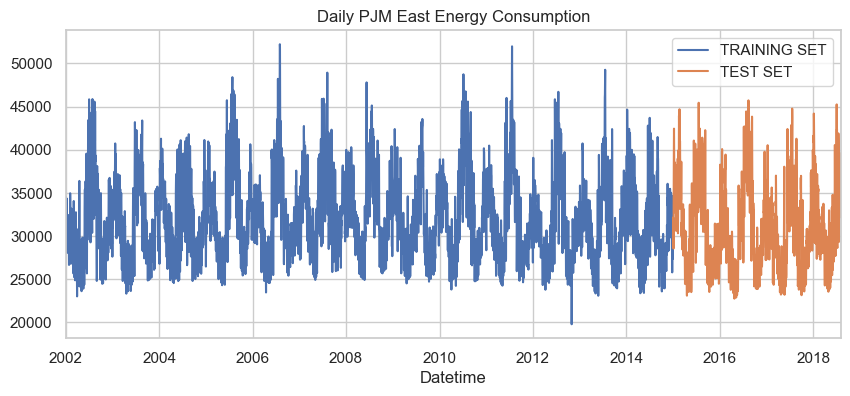

12:24:56 - cmdstanpy - INFO - Chain [1] start processing
12:24:56 - cmdstanpy - INFO - Chain [1] done processing
12:24:56 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
12:24:56 - cmdstanpy - INFO - Chain [1] start processing
12:24:56 - cmdstanpy - INFO - Chain [1] done processing
12:24:56 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


RuntimeError: Error during optimization! Command 'C:\Users\sulem\anaconda3\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=8765 data file=C:\Users\sulem\AppData\Local\Temp\tmp_1rs0at3\s2du281v.json init=C:\Users\sulem\AppData\Local\Temp\tmp_1rs0at3\u4g77pzc.json output file=C:\Users\sulem\AppData\Local\Temp\tmp_1rs0at3\prophet_modelawy9se61\prophet_model-20260301122456.csv method=optimize algorithm=newton iter=10000' failed: 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import seaborn as sns
from sklearn.metrics import r2_score
import os

# Prevent Windows threading crashes
os.environ['FOR_DISABLE_CONSOLE_CTRL_HANDLER'] = '1'

# 1. Load and Optimize Memory Immediately
data = pd.read_csv("C:\\Users\\sulem\\Desktop\\Codes\\ML\\Datasets\\PJME_hourly.csv", parse_dates=['Datetime'], index_col='Datetime')
data = data.sort_index()

# RAM SAVER: Resample to Daily Mean. 
# This reduces the rows by 24x while keeping the overall trend and seasonality.
data = data.resample('D').mean() 

# 2. Split Data
split_date = '2015-01-01'
train_data = data.loc[data.index <= split_date].copy()
test_data = data.loc[data.index > split_date].copy()

# 3. Visualization (Optional - good for checking the split)
sns.set_theme(style="whitegrid")
pal = sns.color_palette()
ax = train_data.rename(columns={'PJME_MW': 'TRAINING SET'}).plot(figsize=(10, 4), color=pal[0])
test_data.rename(columns={'PJME_MW': 'TEST SET'}).plot(ax=ax, color=pal[1])
plt.title('Daily PJM East Energy Consumption')
plt.show()

# 4. Format for Prophet
prophet_train = train_data.reset_index().rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'})

# 5. Fit the Model (Using all daily data is fine for 8GB RAM)
model = Prophet()
model.fit(prophet_train)

# 6. Forecasting 
# Note: periods=len(test_data) works because both are now daily ('D')
future = model.make_future_dataframe(periods=len(test_data), freq='D')
forecast = model.predict(future)

# 7. Evaluation
# We align the forecast with the test data
predictions = forecast.set_index('ds').loc[test_data.index.min():]['yhat']
evaluation_df = test_data.join(predictions, how='inner')

print("R-squared Score on Daily Test Set:",r2_score(evaluation_df['PJME_MW'], evaluation_df['yhat']))

# 8. Final Plot
fig = model.plot(forecast)
plt.title('Prophet Forecast (Daily Resampled)')
plt.show()

# The code can't predit due to RAM.
